In [1]:
from imports_IBM_NM import *
%load_ext autoreload
%autoreload 2
import qiskit as qk
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
from qiskit import pulse
from qiskit import schedule as build_schedule
from qiskit.pulse import ControlChannel, DriveChannel, GaussianSquare, Drag
from qiskit.providers.fake_provider import FakeLagos
import qutip as qt
from qutip import sigmaz, sigmax, sigmay, identity, tensor
from qutip.solver import Options

In [2]:
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif')
plot_colors = ['#9A0EEA','#BF77F6','#030AA7','#0165FC','#39AD48','#F97306','#F7022A']

## Section 1: Hardware Timing (ibm_lagos via FakeLagos)

In [3]:
# Load FakeLagos backend to recover timing parameters
backend = FakeLagos()
config   = backend.configuration()
defaults = backend.defaults()
basis_gates = config.basis_gates
inst_map    = defaults.instruction_schedule_map

ddt        = config.dt * 1e6          # time step in us
X_time     = ddt * 112                # X gate duration (112 samples)
CR_time    = 0.576                    # ECR gate duration in us
CRpm_time  = (CR_time - 2*X_time) / 2  # duration of each CR half-pulse (CRp45_X_CRm45_X has two X gates)

print(f"Time step:    {ddt:.6f} us")
print(f"X gate time:  {X_time:.6f} us")
print(f"CR gate time: {CR_time:.6f} us")
print(f"CRpm time:    {CRpm_time:.6f} us")

Time step:    0.000222 us
X gate time:  0.024889 us
CR gate time: 0.576000 us
CRpm time:    0.263111 us


In [4]:
# Extract pulse envelopes from the default ECR schedule
ecr_circ = QuantumCircuit(2)
ecr_circ.ecr(0, 1)
ecr_transpiled = transpile(ecr_circ, backend, optimization_level=0)
schedule = build_schedule(ecr_transpiled, backend)

d0 = DriveChannel(0)
d1 = DriveChannel(1)
u0 = ControlChannel(0)

pulse_pd1 = schedule.instructions[7][1].pulse   # CRp45 on d1
pulse_pu0 = schedule.instructions[8][1].pulse   # CRp45 on u0
pulse_X0  = schedule.instructions[9][1].pulse   # X on d0
pulse_md1 = schedule.instructions[10][1].pulse  # CRm45 on d1
pulse_mu0 = schedule.instructions[11][1].pulse  # CRm45 on u0

print("Pulse envelopes extracted from FakeLagos ECR schedule:")
print(f"  CRp45 d1: {pulse_pd1}")
print(f"  CRp45 u0: {pulse_pu0}")
print(f"  X    d0:  {pulse_X0}")
print(f"  CRm45 d1: {pulse_md1}")
print(f"  CRm45 u0: {pulse_mu0}")

Pulse envelopes extracted from FakeLagos ECR schedule:
  CRp45 d1: GaussianSquare(duration=528, sigma=64, width=272, amp=0.05953503000783375, angle=0.010451965507347198, name='CR90p_d1_u0')
  CRp45 u0: GaussianSquare(duration=528, sigma=64, width=272, amp=0.6677105784777229, angle=-2.543009715153759, name='CR90p_u0')
  X    d0:  Drag(duration=160, sigma=40, beta=-0.06760800029241476, amp=0.1937108374546353, angle=0.0, name='Xp_d0')
  CRm45 d1: GaussianSquare(duration=528, sigma=64, width=272, amp=0.05953503000783375, angle=-3.131140688082446, name='CR90m_d1_u0')
  CRm45 u0: GaussianSquare(duration=528, sigma=64, width=272, amp=0.6677105784777229, angle=0.5985829384360342, name='CR90m_u0')


## Section 2: ECR Gate Tomography Circuits

The ECR gate is implemented as CRp45 – X0 – CRm45 – X0 (cross-resonance sequence).
Circuits are generated for:
- 32 repetitions of the ECR gate (n = 0 … 31)
- 3 measured observables: X, Y, Z on the target qubit (q1)
- 2 initial control-qubit states: |00⟩, |01⟩ (plus |0+⟩ for completeness)

Total: 3 × 32 × 3 = 288 circuits.  Saved to `../data/CRp45_X_CRm45_X-Utom-circs-lagos.p`.

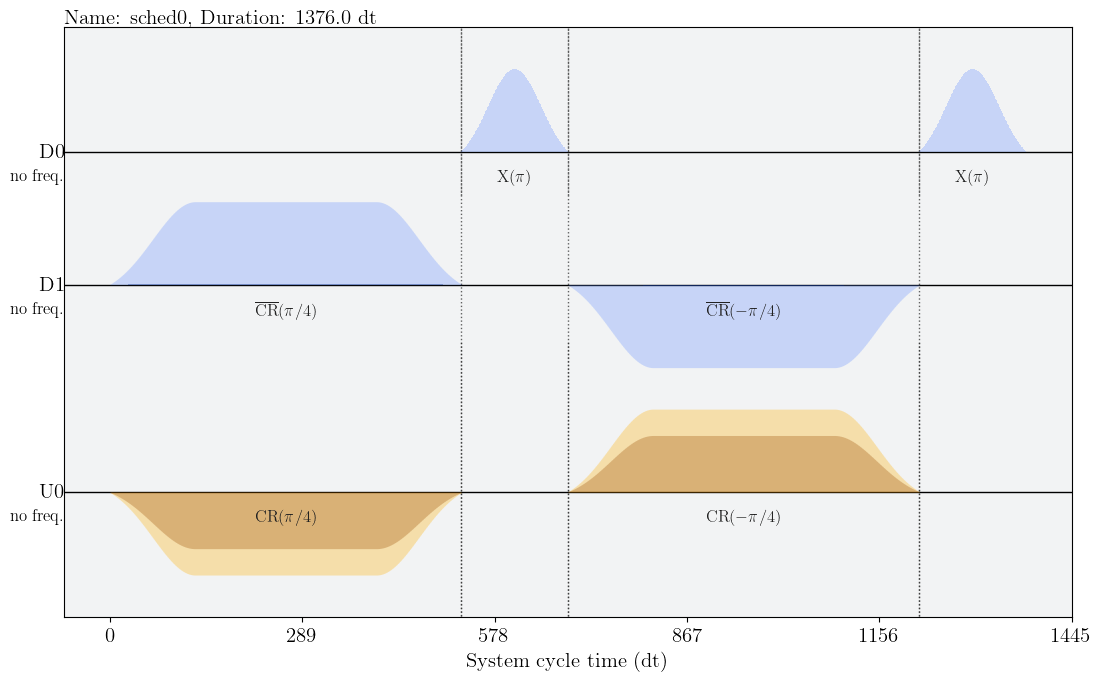

Generated 288 circuits
Circuits saved to ../data/CRp45_X_CRm45_X-Utom-circs-lagos.p


In [5]:
gate_name = 'cr'

# Register the ECR gate in the instruction map
sched_ecr = pulse.Schedule()
sched_ecr += pulse.Play(pulse_pd1, d1)
sched_ecr += pulse.Play(pulse_pu0, u0)
sched_ecr += pulse.instructions.RelativeBarrier(d0, d1, u0)
sched_ecr += pulse.Play(pulse_X0, d0)
sched_ecr += pulse.instructions.RelativeBarrier(d0, d1, u0)
sched_ecr += pulse.Play(pulse_md1, d1)
sched_ecr += pulse.Play(pulse_mu0, u0)
sched_ecr += pulse.instructions.RelativeBarrier(d0, d1, u0)
sched_ecr += pulse.Play(pulse_X0, d0)
inst_map.add(gate_name, [0, 1], sched_ecr)
display(sched_ecr.draw())

basis_gates_cr = ['id', 'rz', 'sx', 'x', gate_name]
cr_gate = qk.circuit.Gate(gate_name, 2, [])

num_CR = 32
nn     = np.arange(num_CR)

circuits = {}
for exp_val in ['X', 'Y', 'Z']:
    for n in range(num_CR):
        for state in ['00', '01', '0p']:
            qr, cr = qk.QuantumRegister(2), qk.ClassicalRegister(2)
            circ = qk.QuantumCircuit(qr, cr)

            # --- state preparation ---
            if state == '00':
                circ.id(0); circ.id(1)
            elif state == '01':
                circ.id(1); circ.x(0)
            elif state == '0p':
                circ.id(1); circ.sx(0)

            # --- n ECR gates ---
            inst_map.add(gate_name, [0, 1], sched_ecr)
            cr_gate = qk.circuit.Gate(gate_name, 2, [])
            for _ in range(n):
                circ.append(cr_gate, qargs=[qr[0], qr[1]])

            # --- observable rotation ---
            if exp_val == 'Y':      # sXdg
                circ.z(qr[1]); circ.sx(qr[1]); circ.z(qr[1])
            elif exp_val == 'X':    # sYdg
                circ.sx(qr[1]); circ.s(qr[1]); circ.sx(qr[1]); circ.z(qr[1])
            # Z: no rotation needed

            circ.measure(qr, cr)

            # --- add custom ECR calibration ---
            with pulse.build(backend, name=gate_name) as cr_q01:
                pulse.play(pulse_pd1, d1); pulse.play(pulse_pu0, u0)
                pulse.barrier(d0, d1, u0)
                pulse.play(pulse_X0, d0)
                pulse.barrier(d0, d1, u0)
                pulse.play(pulse_md1, d1); pulse.play(pulse_mu0, u0)
                pulse.barrier(d0, d1, u0)
                pulse.play(pulse_X0, d0)
            circ.add_calibration(gate_name, [0, 1], cr_q01)

            circ = transpile(circ, backend, basis_gates_cr, optimization_level=0)
            circuits[f'{exp_val}-{n}-{state}'] = circ

assert len(circuits) == 288
print(f"Generated {len(circuits)} circuits")
pk.dump(circuits, open('../data/CRp45_X_CRm45_X-Utom-circs-lagos.p', 'wb'))
print("Circuits saved to ../data/CRp45_X_CRm45_X-Utom-circs-lagos.p")

## Section 3: Load Experiment Data

Circuits were run on `ibm_lagos` (job ID: `cmskyrvvpdgg008gb7ag`) with 100 000 shots.
Pre-processed expectation-value data is loaded from `../data/data_FIG7.p`.

> **Note:** To recreate `data_FIG7.p` from raw IBM Quantum results, run the
> optional IBM retrieval block below (requires an active IBM Quantum account
> and the `qiskit-ibm-provider` package), then save with the final line.

In [6]:
# ── Optional: retrieve from IBM Quantum (requires live credentials) ──────────
# token    = '<YOUR_TOKEN>'
# provider = qiskit_ibm_provider.IBMProvider(token)
# backend_name = 'ibm_lagos'
# job_id   = 'cmskyrvvpdgg008gb7ag'
# job      = get_jobs_from_ids(job_id, provider, backend_name)
# results  = job.result()
# counts   = results.get_counts()
# shots    = np.sum(list(counts[0].values()))
#
# basis2Q = ['00', '01', '10', '11']
# raw_counts = np.array([[c[b]/shots for b in basis2Q] for c in counts])
#
# mit_evals = {}
# for i, ev in enumerate(['X', 'Y', 'Z']):
#     mit_evals[ev] = {}
#     counts_ev = np.around(raw_counts[i*num_CR*3:(i+1)*num_CR*3], 3)
#     for k, s in enumerate(basis2Q):
#         mit_evals[ev][s] = counts_ev[k::3]
#
# smod2 = lambda a, b: str((int(a)+int(b)) % 2)
# def get_index(s, q):
#     if q == 0: return basis2Q.index(smod2(s[0],1) + smod2(s[1],0))
#     elif q == 1: return basis2Q.index(smod2(s[0],0) + smod2(s[1],1))
#
# ps_exp = {}
# for ev, ps_ev in mit_evals.items():
#     ps_exp[ev] = {}
#     for k, (s, ps_ev_s) in enumerate(ps_ev.items()):
#         ps_exp[ev][s] = (
#             np.array([c[k] + c[get_index(s,0)] for c in ps_ev_s]),
#             np.array([c[k] + c[get_index(s,1)] for c in ps_ev_s])
#         )
# pk.dump(ps_exp, open('../data/data_FIG7.p', 'wb'))
# ─────────────────────────────────────────────────────────────────────────────

print("Loaded ev_exp from ../data/data_FIG7.p")
ev_exp = pk.load(open('../data/data_FIG7.p', 'rb'))

tt = nn * CR_time

Loaded ev_exp from ../data/data_FIG7.p


## Section 4: QuTiP Simulation

Open-system simulation of the ECR gate using the Lindblad master equation.
The Hamiltonian contains:
- ZX drive at frequency ω = π / (2·t_CR) × 1.14 (cross-resonance tone)
- IX stray coupling ζ = π / t_CR × 0.002 (always-on)
- XI control drive π / (2·t_X) during X-gate windows

Lindblad operators model T1 decay, pure dephasing, SPAM errors,
and gate-induced dephasing on both qubits.

In [7]:
# ── Pauli / tensor operators ─────────────────────────────────────────────────
X_op = sigmax(); Y_op = sigmay(); Z_op = sigmaz(); I_op = identity(2)

XI = tensor(X_op, I_op); IX = tensor(I_op, X_op)
ZI = tensor(Z_op, I_op); IZ = tensor(I_op, Z_op)
ZX = tensor(Z_op, X_op)

a_op  = 0.5 * (sigmax() + 1j*sigmay())
I_op2 = identity(2)
aI = tensor(a_op, I_op2)
Ia = tensor(I_op2, a_op)

# ── Initial states ───────────────────────────────────────────────────────────
psi_0 = qt.states.basis(2, 0); psi_1 = qt.states.basis(2, 1)
psi_00 = tensor(psi_0, psi_0); psi_10 = tensor(psi_1, psi_0)
rho_00 = qt.ket2dm(psi_00);    rho_10 = qt.ket2dm(psi_10)

# ── SPAM error model ─────────────────────────────────────────────────────────
def ME(rho, spam0, spam1):
    rho_e = (1 - spam0)*rho    + spam0 * XI*rho*XI
    rho_e = (1 - spam1)*rho_e  + spam1 * IX*rho_e*IX
    return rho_e

# ── Time-dependent Hamiltonian coefficient functions ─────────────────────────
def ZX_time_fun(t, args):
    t_mod = t % CR_time
    if   t_mod <= CRpm_time:                           return  1
    elif t_mod <= CRpm_time + X_time:                  return  0
    elif t_mod <= 2*CRpm_time + X_time:                return -1
    else:                                              return  0

def X0_time_fun(t, args):
    t_mod = t % CR_time
    if   t_mod <= CRpm_time:                           return 0
    elif t_mod <= CRpm_time + X_time:                  return 1
    elif t_mod <= 2*CRpm_time + X_time:                return 0
    else:                                              return 1

# ── Noise parameters (from paper Table I, qubit 0 & 1 on ibm_lagos) ─────────
omega  = np.pi / CR_time / 2 * 1.097   # ZX drive strength (rad/us)
zeta   = np.pi / CR_time * 0.00      # IX stray coupling (rad/us)

gamma0 = 0.01602   # T1 decay rate qubit 0 (1/us)
lmbda0 = 0.0129    # pure dephasing qubit 0 (1/us)
spam0  = 0.01      # SPAM error qubit 0

gamma1 = 0.0117    # T1 decay rate qubit 1 (1/us)
lmbda1 = 0.0001    # pure dephasing qubit 1 (1/us)
spam1  = 0.031     # SPAM error qubit 1
nu0    = 0.0       # gate dephasing qubit 0 (1/us)
nu1    = 0.05      # gate dephasing qubit 1 (1/us)

# ── Hamiltonian and Lindblad operators ───────────────────────────────────────
H = [
    zeta * IX / 2,
    [-omega/2 * ZX,              ZX_time_fun],
    [np.pi/2/X_time * XI,        X0_time_fun],
]

L_ops = [
    np.sqrt(gamma0/2) * aI,
    np.sqrt(gamma1/2) * Ia,
    np.sqrt(lmbda0/2) * ZI,
    np.sqrt(lmbda1/2) * IZ,
    np.sqrt(nu1/2)    * IX,
    np.sqrt(nu0/2)    * XI,
]

print(f"omega = {omega:.5f} rad/us  (ZX drive)")
print(f"zeta  = {zeta:.5f} rad/us  (IX stray)")

omega = 2.99160 rad/us  (ZX drive)
zeta  = 0.00000 rad/us  (IX stray)


In [8]:
# ── Run mesolve for both initial states ───────────────────────────────────────
tt_exp = nn * CR_time   # time points at end of each ECR repetition

ev_sim = {}
for k, rho0 in enumerate([rho_00, rho_10]):
    result = qt.mesolve(H, rho0, tt_exp, L_ops,
                        options=Options(store_states=True))
    ev_sim[k] = {
        ev: np.array([
            (op * ME(rho, spam0, spam1).ptrace(1)).tr().real
            for rho in result.states
        ])
        for ev, op in {'X': X_op, 'Y': Y_op, 'Z': Z_op}.items()
    }

print("Simulation complete.")
print(f"  ev_sim[0] keys: {list(ev_sim[0].keys())}  shape: {ev_sim[0]['Y'].shape}")

Simulation complete.
  ev_sim[0] keys: ['X', 'Y', 'Z']  shape: (32,)


## Section 5: Paper Figure

Two-panel figure (⟨Y⟩ and ⟨Z⟩ vs gate repetitions) for initial states
|00⟩ and |01⟩ of the control qubit.
Solid lines: simulation; open circles: experiment.

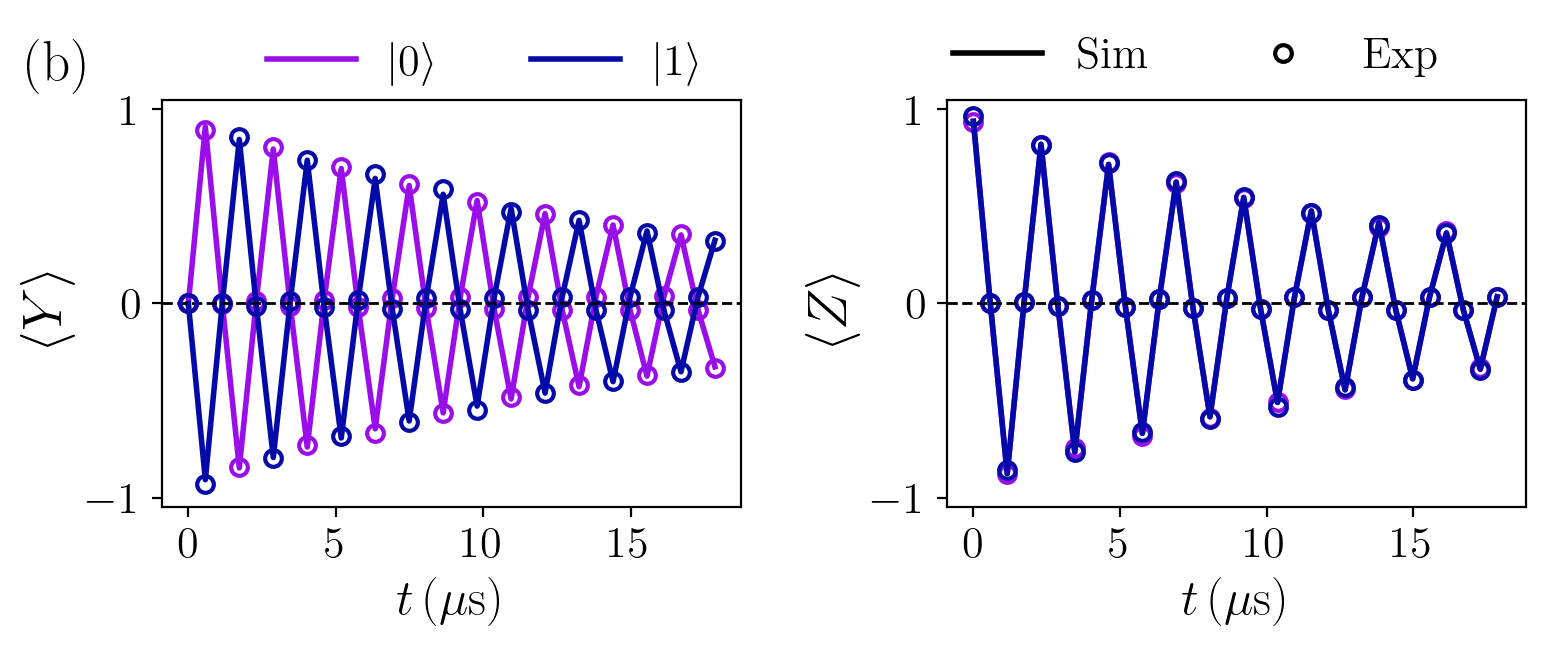

Saved: ../figures/fig_07_ecr_gate.pdf


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), dpi=200)

for col, ev in enumerate(['Y', 'Z']):
    ax = axes[col]
    for k, s in enumerate(['00', '01']):
        color = plot_colors[k*2]
        # simulation
        ax.plot(tt, ev_sim[k][ev], color=color, lw=2)
        # experiment
        ax.plot(tt, ev_exp[k][ev],
                color=color, marker='o', mfc='none', ls='', markeredgewidth=1.5)

    ax.set_ylim(-1.05, 1.05)
    ax.set_xlabel(r'$t\,(\mu\mathrm{s})$', size=18)
    ax.set_ylabel(r'$\langle %s \rangle$' % ev, size=20)
    ax.axhline(0, lw=1, ls='--', color='k')
    ax.tick_params(labelsize=16)

    if col == 0:
        # state legend
        for k, s in enumerate(['00', '01']):
            ax.plot(0, 0, label=r'$|%s\rangle$' % s[1],
                    color=plot_colors[k*2], lw=2)
            ax.plot(0, 0, color=plot_colors[k*2],
                    marker='o', mfc='none', ls='', markeredgewidth=1.5)
        ax.legend(frameon=False, fontsize=16, ncol=2,
                  bbox_to_anchor=(1.01, 1.24))
        ax.text(-5.5, 1.15, "(b)", size=20)
    if col == 1:
        ax.plot(-2, 0, label='Sim', color='k', lw=2)
        ax.plot(-2, 0, color='k', label='Exp',
                marker='o', mfc='none', ls='', markeredgewidth=1.5)
        ax.set_xlim(left=-0.9)
        ax.legend(frameon=False, fontsize=16, ncol=2,
                  bbox_to_anchor=(0.92, 1.25))

plt.tight_layout()
plt.savefig('../figures/fig_07_ecr_gate.pdf', bbox_inches='tight')
plt.show()
print("Saved: ../figures/fig_07_ecr_gate.pdf")